In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from typing import Tuple, List
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import numpy as np


212.0


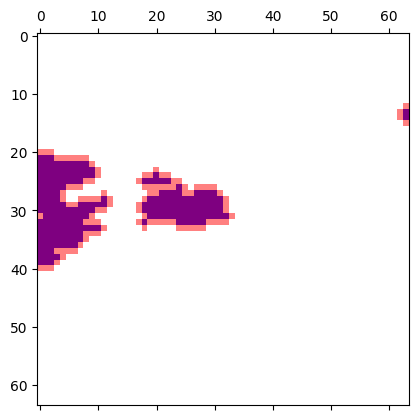

In [ ]:
base = "C:\\Users\\rball\\OneDrive\\Documents\\school\\00 GRADUATE\\Thesis\\03DataVisualization\\mid-process-data-files\\csv-files\\"
filename = "train_08.csv"
currfile = base + filename
df = pd.read_csv(currfile)
realtarget = df["FireMask"]
prevmask = df["PrevFireMask"]
w = 64
h = 64
prevmask = prevmask.values.reshape(w, h, 1)
faketarget = np.zeros((w, h, 1))

dataiter = np.nditer(prevmask, flags=['multi_index'])
for elem in dataiter:
    #print(elem)
    if elem==1:
        #print(dataiter.multi_index, elem)
        br = dataiter.multi_index[0]
        bc = dataiter.multi_index[1]
        faketarget[br][bc][0] = 1.0                                # [r][c]= 1.0 (copying prev mask fires)
        if (br - 1) >= 0: faketarget[br-1][bc][0] = 1.0     # [r-1][c]
        if (br + 1) < w: faketarget[br+1][bc][0] = 1.0      # [r][c-1]
        if (bc - 1) >= 0: faketarget[br][bc-1][0] = 1.0     # [r][c+1]
        if (bc + 1) < h: faketarget[br][bc+1][0] = 1.0      # [r+1][c]
        
    if elem==-1:
        prevmask[dataiter.multi_index] = 0.0
        #pass

print(np.sum(prevmask))
cmap1 = mcolors.ListedColormap(["none", "red"])
cmap2 = mcolors.ListedColormap(["none", "blue"])

plt.figure()
plt.matshow(prevmask, cmap=cmap2, fignum=1)
plt.imshow(faketarget, cmap=cmap1, alpha=0.5)
plt.show()

# plt.figure()
# plt.imshow(prevmask, cmap="gray_r")
# plt.show()

target = faketarget
data = df.drop('FireMask', axis=1)                          # pd dataframe
data = data.values.reshape(64, 64, 12).astype(np.float32)   # numpy array



In [ ]:
def fakeTarget(prevmask, hw):
    prevmask_r = prevmask.values.reshape(hw, hw, 1)
    faketarget = np.zeros((hw, hw, 1))
    ditr = np.nditer(prevmask_r, flags=['multi_index'])

    for elem in ditr:
        if elem==1:
            br = ditr.multi_index[0]
            bc = ditr.multi_index[1]
            faketarget[br][bc][0] = 1.0                                # [r][c]= 1.0 (copying prev mask fires)
            if (br - 1) >= 0: faketarget[br-1][bc][0] = 1.0     # [r-1][c]
            if (br + 1) < w: faketarget[br+1][bc][0] = 1.0      # [r][c-1]
            if (bc - 1) >= 0: faketarget[br][bc-1][0] = 1.0     # [r][c+1]
            if (bc + 1) < h: faketarget[br][bc+1][0] = 1.0      # [r+1][c]
            
    return faketarget

In [ ]:
class FireDataset(Dataset):

    def __init__(self, file_paths:List[str], data_size=64, crop_size=32, in_channels=12, 
                 clip_and_norm=True, clip_and_rescale=False, 
                 random_crop=True, center_crop=False):
        
        self.file_paths = file_paths
        self.center_crop = center_crop
        self.random_crop = random_crop
        self.clip_and_norm = clip_and_norm
        self.clip_and_rescale = clip_and_rescale
        self.data_size = data_size
        self.crop_size = crop_size
        self.in_channels = in_channels

        # read in all samples at once: leave preprocessing to getitem() method
        self.in_images = []
        self.labels = []
        self.base_dir = "C:\\Users\\rball\\OneDrive\\Documents\\school\\00 GRADUATE\\Thesis\\03DataVisualization\\mid-process-data-files\\csv-files\\"
        for file in self.file_paths:
            curr_file = self.base_dir + file
            df = pd.read_csv(curr_file)

            # can't just select the first column since they are not always in order
            target = df["FireMask"].astype(np.float32)
            target = target.values.reshape(64, 64, 1)

            data = df.drop('FireMask', axis=1).astype(np.float32)
            data = data[INPUT_FEATURES] # sort features into consistent order
            data = data.values.reshape(64, 64, 12)
            
            # permute to get in shape CHW. DONT unsqueeze for batch dim as that is added by DataLoader!!!!
            image = torch.tensor(data, dtype=torch.float32).permute(2,0,1)
            self.in_images.append(image)

            label = torch.tensor(target, dtype=torch.float32).permute(2,0,1)
            self.labels.append(label)
 
   
    def __len__(self):
        return len(self.file_paths)
    

    def __getitem__(self, idx): # GETITEM RETURNS WITH SIZE CHW
        # in_images is already a list of tensors in the correct shape
        input_img = self.in_images[idx]
        output_img = self.labels[idx]

        if self.random_crop and self.center_crop:
            raise ValueError('Cannot have both random_crop and center_crop be True')

        if self.clip_and_norm:
            transformed = []
            for feature, channel in zip(INPUT_FEATURES, input_img.unbind(dim=0)):
                transformed.append(clip_and_normalize(feature, channel))
            input_img = torch.stack(transformed)
        elif self.clip_and_rescale:
            transformed = []
            for feature, channel in zip(INPUT_FEATURES, input_img.unbind(dim=0)):
                transformed.append(clip_and_rescale(feature, channel))
            input_img = torch.stack(transformed)

        if self.random_crop:
            input_img, output_img = random_crop_io(input_img, output_img, desired_size=self.crop_size, 
                                        num_in_channels=self.in_channels, num_out_channels=1)
        elif self.center_crop:
            input_img, output_img = center_crop_io(input_img, output_img, desired_size=self.crop_size)
            
        #print("input shape:", input_img.shape, " output shape:", output_img.shape )
        return input_img, output_img
        

test_file_paths = ["test_00.csv", "test_01.csv"]
eval_file_paths = ["eval_00.csv", "eval_01.csv"]
train_file_paths = ["train_00.csv", "train_01.csv", "train_02.csv", "train_03.csv", "train_04.csv", 
                    "train_05.csv", "train_06.csv", "train_07.csv", "train_08.csv", "train_09.csv", 
                    "train_10.csv", "train_11.csv", "train_12.csv", "train_13.csv", "train_14.csv"]

test_dataset = FireDataset(test_file_paths, clip_and_norm=False, clip_and_rescale=True)
eval_dataset = FireDataset(eval_file_paths, clip_and_norm=False, clip_and_rescale=True)
train_dataset = FireDataset(train_file_paths, clip_and_norm=False, clip_and_rescale=True)

# eval just needs one sample for validation???
BATCH_SIZE=32
eval_dataloader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)



#print(data)